In [1]:
import matplotlib.pyplot as plt
import numpy as np
import sys
import time
import jax
import jax.numpy as jnp
import jax.scipy as jsp
import numpy as np
import optax
from functools import partial
from typing import Dict, Tuple, Any

import taurex.log
taurex.log.disableLogging()

from taurex.cache import OpacityCache,CIACache
from taurex.contributions import AbsorptionContribution, CIAContribution, RayleighContribution
from taurex.data.spectrum.observed import ObservedSpectrum
from taurex.model import TransmissionModel

from taurex.planet import Planet
from taurex.stellar import BlackbodyStar
from taurex.chemistry import TaurexChemistry, ConstantGas
from taurex.temperature import Isothermal

from experiment import create_binned_forward_model, extract_fitting_params, clip_native_to_wngrid, create_forward_model
from experiment import full_diff_create_forward_model, full_diff_create_binned_forward_model

Numba not installed, using numpy instead


In [2]:
xsec_path = "/Users/asweet/Code/research/taurex3/test_files/Input/xsec/xsec_sampled_R15000_0.3-50"
cia_path = "/Users/asweet/Code/research/taurex3/test_files/Input/cia/HITRAN/data"
obs_path  = "/Users/asweet/Code/research/taurex3/test_files/quickstart.dat"

OpacityCache().clear_cache()
OpacityCache().set_opacity_path(xsec_path)
CIACache().set_cia_path(cia_path)


In [3]:
# Build TauREx model
planet = Planet(planet_radius=1.0, planet_mass=1.0)
star = BlackbodyStar(temperature=5700.0, radius=1.0)

chemistry = TaurexChemistry(fill_gases=['H2','He'], ratio=0.172)
chemistry.addGas(ConstantGas('H2O', mix_ratio=1.2e-4))
chemistry.addGas(ConstantGas('N2', mix_ratio=3.00739e-9))

isothermal = Isothermal(T=1500.0)

tm = TransmissionModel(
    planet=planet,
    temperature_profile=isothermal,
    chemistry=chemistry,
    star=star,
    atm_min_pressure=1e-0,
    atm_max_pressure=1e6,
    nlayers=30
)
tm.add_contribution(AbsorptionContribution())
tm.add_contribution(CIAContribution(cia_pairs=['H2-H2','H2-He']))
tm.add_contribution(RayleighContribution())
tm.build()
tm['H2O'] = 1.2e-4

In [4]:
chemistry.gases

['H2', 'He', 'H2O', 'N2']

In [5]:
print(f"Active gases: {list(tm.chemistry.activeGases)}")
print(f"Fill gases: {list(tm.chemistry._fill_gases)}")

Active gases: ['H2O']
Fill gases: ['H2', 'He']


In [6]:
# Load observations
obs = ObservedSpectrum(obs_path)

# Setup observed data
obs_y = jnp.asarray(obs.spectrum)
if hasattr(obs, "errorBar"):
    obs_err = jnp.asarray(obs.errorBar)
else:
    obs_err = 0.02 * jnp.maximum(jnp.abs(obs_y), 1e-12)

# Create binned forward model - THIS IS THE KEY MISSING PIECE
# forward_binned = create_binned_forward_model(tm, obs)
forward_binned = full_diff_create_binned_forward_model(tm, obs)

Pre-loading opacities for gases: ('H2O',)
Loading H2O opacity: T=27, P=22, WN=76744
[binning] W shape: (192, 29685), empty rows: 0, partial rows: 0
[grids] high-res N=29685, bins=192, observed points=192


In [7]:
high_res_wngrid = clip_native_to_wngrid(
    tm.nativeWavenumberGrid,
    obs.wavenumberGrid
)

# Ensure increasing order for safety
if high_res_wngrid[0] > high_res_wngrid[-1]:
    high_res_wngrid = high_res_wngrid[::-1]

bin_edges = obs.binEdges
if bin_edges[0] > bin_edges[-1]:
    bin_edges = bin_edges[::-1]

# 2) JAX forward model at high resolution
# jax_forward_model = create_forward_model(tm, high_res_wngrid)
jax_forward_model = full_diff_create_forward_model(tm, high_res_wngrid)

Pre-loading opacities for gases: ('H2O',)
Loading H2O opacity: T=27, P=22, WN=76744


In [8]:
params, param_info = extract_fitting_params(tm)

In [9]:
full_absoprtion, full_tau = jax_forward_model(params)

In [10]:
obin = obs.create_binner()

In [11]:
taurex_full_absorption = tm.model(obs.wavenumberGrid)[1]

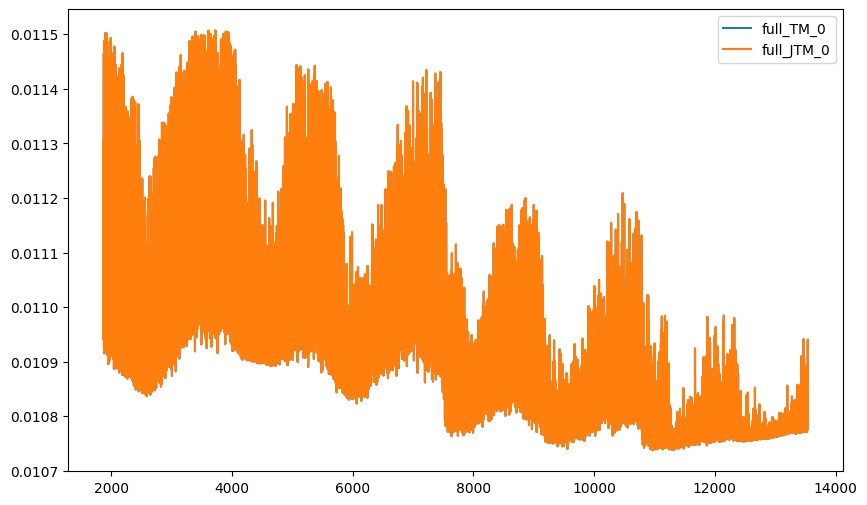

In [12]:
plt.figure(figsize=(10, 6))
plt.plot(high_res_wngrid, taurex_full_absorption, label="full_TM_0")
plt.plot(high_res_wngrid, full_absoprtion, label="full_JTM_0")
plt.legend()
plt.show()

In [13]:
params

{'planet_mass': Array(1., dtype=float64, weak_type=True),
 'planet_radius': Array(1., dtype=float64, weak_type=True),
 'planet_distance': Array(1., dtype=float64, weak_type=True),
 'planet_sma': Array(1., dtype=float64, weak_type=True),
 'distance': Array(1., dtype=float64, weak_type=True),
 'atm_min_pressure': Array(1., dtype=float64, weak_type=True),
 'atm_max_pressure': Array(1000000., dtype=float64, weak_type=True),
 'T': Array(1500., dtype=float64, weak_type=True),
 'H2O': Array(0.00012, dtype=float64, weak_type=True),
 'N2': Array(3.00739e-09, dtype=float64, weak_type=True),
 'He_H2': Array(0.172, dtype=float64, weak_type=True)}

In [14]:
tm_y = obin.bin_model(tm.model(obs.wavenumberGrid))[1]

jtm_y = np.array(forward_binned(params))

params['H2O'] = np.array(1e-4)
params['planet_radius'] = np.array(0.9777810779205119)
params['T'] = np.array(1496.606399794941)
jtm_y_fit = np.array(forward_binned(params))

tm['H2O'] = 1e-4
tm['planet_radius'] = 0.9777810779205119
tm['T'] = 1496.606399794941

tm_y_fit = obin.bin_model(tm.model(obs.wavenumberGrid))[1]

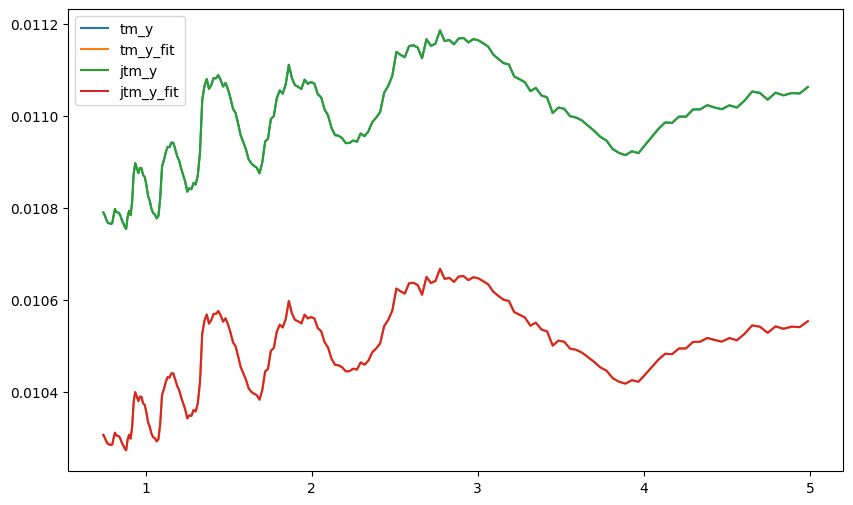

In [15]:
plt.figure(figsize=(10, 6))
# plt.errorbar(obs.wavelengthGrid, obs.spectrum, obs.errorBar, label='Obs')
plt.plot(obs.wavelengthGrid, tm_y, label='tm_y')
plt.plot(obs.wavelengthGrid, tm_y_fit, label='tm_y_fit')

plt.plot(obs.wavelengthGrid, jtm_y, label='jtm_y')
plt.plot(obs.wavelengthGrid, jtm_y_fit, label='jtm_y_fit')
plt.legend()
plt.show()

In [19]:
params

params['H2O'] = np.array(1e-4)
params['planet_radius'] = np.array(0.9777810779205119)
params['T'] = np.array(1496.606399794941)

{'planet_mass': Array(1., dtype=float64, weak_type=True),
 'planet_radius': Array(1., dtype=float64, weak_type=True),
 'planet_distance': Array(1., dtype=float64, weak_type=True),
 'planet_sma': Array(1., dtype=float64, weak_type=True),
 'distance': Array(1., dtype=float64, weak_type=True),
 'atm_min_pressure': Array(1., dtype=float64, weak_type=True),
 'atm_max_pressure': Array(1000000., dtype=float64, weak_type=True),
 'T': Array(1500., dtype=float64, weak_type=True),
 'H2O': Array(0.00012, dtype=float64, weak_type=True),
 'N2': Array(3.00739e-09, dtype=float64, weak_type=True),
 'He_H2': Array(0.172, dtype=float64, weak_type=True)}

In [12]:
initial_pred = np.array(forward_binned(params))


(jtm) density_profile: Traced<ShapedArray(float64[30])>with<DynamicJaxprTrace>
(jtm) molecular_contribution: Traced<ShapedArray(float64[30,29685])>with<DynamicJaxprTrace>
(jtm) other_contribs_sigma: [[8.63845966e-36 8.64076411e-36 8.64306918e-36 ... 2.43283913e-32
  2.43349736e-32 2.43415578e-32]
 [8.63845966e-36 8.64076411e-36 8.64306918e-36 ... 2.43283913e-32
  2.43349736e-32 2.43415578e-32]
 [8.63845966e-36 8.64076411e-36 8.64306918e-36 ... 2.43283913e-32
  2.43349736e-32 2.43415578e-32]
 ...
 [8.63845966e-36 8.64076411e-36 8.64306918e-36 ... 2.43283913e-32
  2.43349736e-32 2.43415578e-32]
 [8.63845966e-36 8.64076411e-36 8.64306918e-36 ... 2.43283913e-32
  2.43349736e-32 2.43415578e-32]
 [8.63845966e-36 8.64076411e-36 8.64306918e-36 ... 2.43283913e-32
  2.43349736e-32 2.43415578e-32]]
(jtm) total_sigma: Traced<ShapedArray(float64[30,29685])>with<DynamicJaxprTrace>
(jtm) path_lengths: [Traced<ShapedArray(float64[30])>with<DynamicJaxprTrace>, Traced<ShapedArray(float64[29])>with<Dynam

NameError: name 'final_params' is not defined